In [1]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')

print(orders.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [2]:
print("Dataset Shape:")
print(orders.shape)

print("\nColumn Names:")
print(orders.columns)

print("\nData Types:")
print(orders.dtypes)

print("\nMissing Values:")
print(orders.isnull().sum())

Dataset Shape:
(99441, 8)

Column Names:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

Data Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [3]:
print("Duplicate Rows:", orders.duplicated().sum())

Duplicate Rows: 0


In [4]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [5]:
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)

Order Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)
Customers: (99441, 5)


In [6]:
# Merge order items with products

sales_data = pd.merge(
    order_items,
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print(sales_data.head())
print(sales_data.shape)

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value product_category_name  
0  2017-09-19 09:45:35   58.90          13.29            cool_stuff  
1  2017-05-03 11:05:13  239.90          19.93              pet_shop  
2  2018-01-18 14:48:30  19

In [7]:
category_revenue = sales_data.groupby(
    'product_category_name'
)['price'].sum().sort_values(ascending=False)

print(category_revenue.head(10))

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64


In [8]:
print("Highest Revenue Category:")
print(category_revenue.idxmax())

print("\nRevenue:")
print(category_revenue.max())

Highest Revenue Category:
beleza_saude

Revenue:
1258681.34


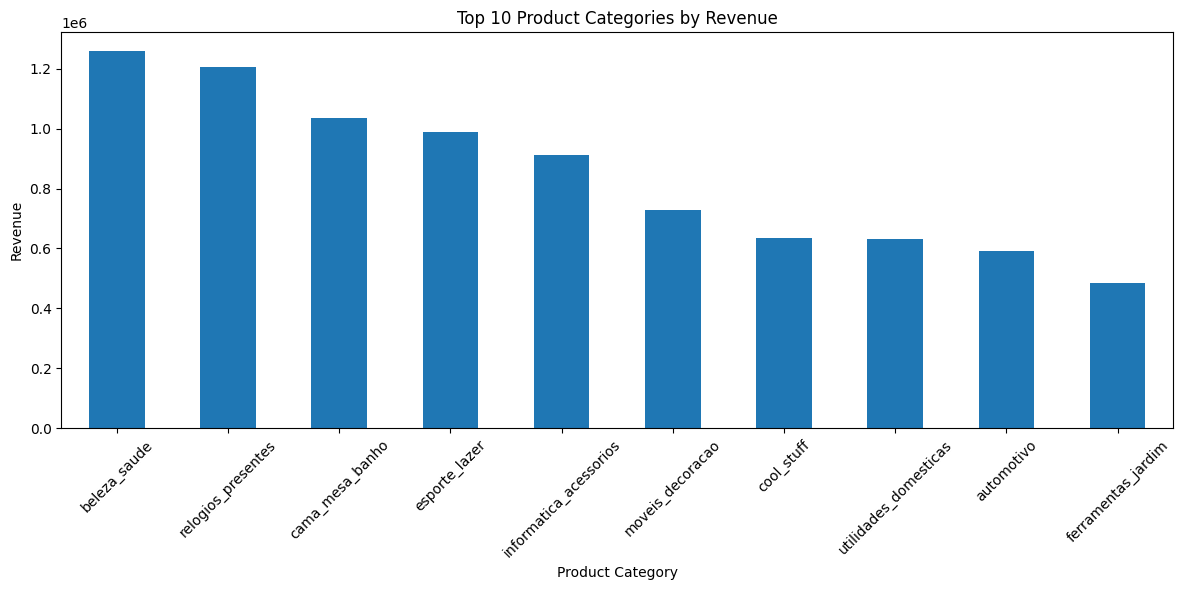

In [9]:
import matplotlib.pyplot as plt

top10 = category_revenue.head(10)

plt.figure(figsize=(12,6))
top10.plot(kind='bar')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [10]:
# Create month column
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Count orders per month
monthly_sales = orders.groupby('month').size()

print(monthly_sales.sort_values(ascending=False).head(10))

month
2017-11    7544
2018-01    7269
2018-03    7211
2018-04    6939
2018-05    6873
2018-02    6728
2018-08    6512
2018-07    6292
2018-06    6167
2017-12    5673
Freq: M, dtype: int64


In [11]:
print("Peak Sales Month:")
print(monthly_sales.idxmax())

print("\nNumber of Orders:")
print(monthly_sales.max())

Peak Sales Month:
2017-11

Number of Orders:
7544


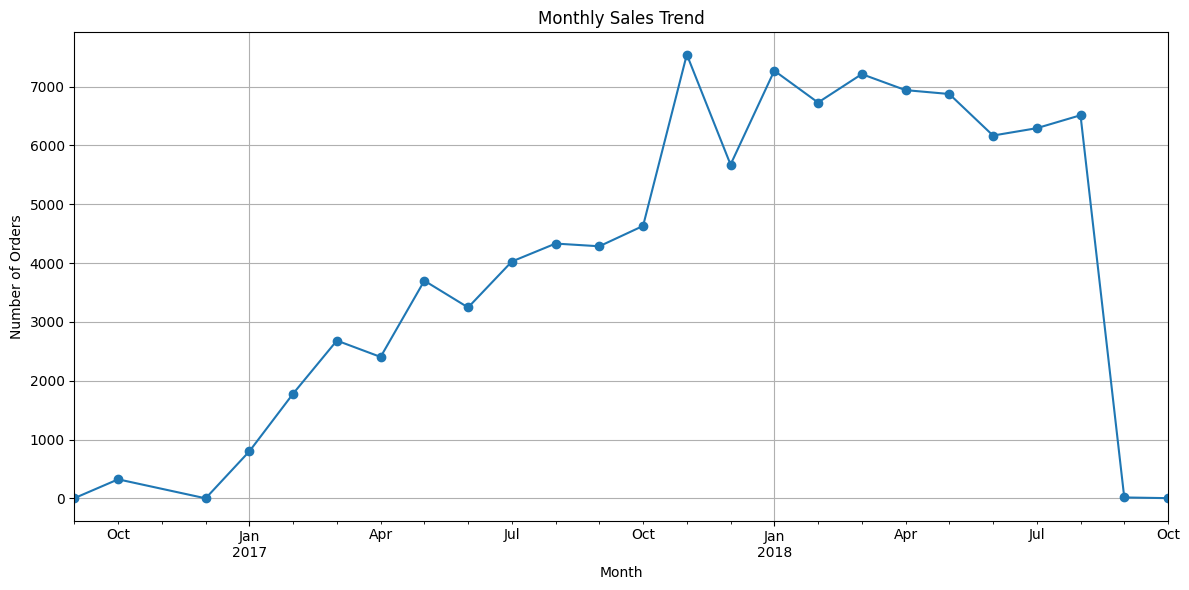

In [12]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Merge orders with customers

region_data = pd.merge(
    orders,
    customers,
    on='customer_id',
    how='left'
)

print(region_data.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15

In [14]:
# Orders by state

state_orders = region_data.groupby(
    'customer_state'
).size().sort_values(ascending=False)

print(state_orders.head(10))

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
dtype: int64


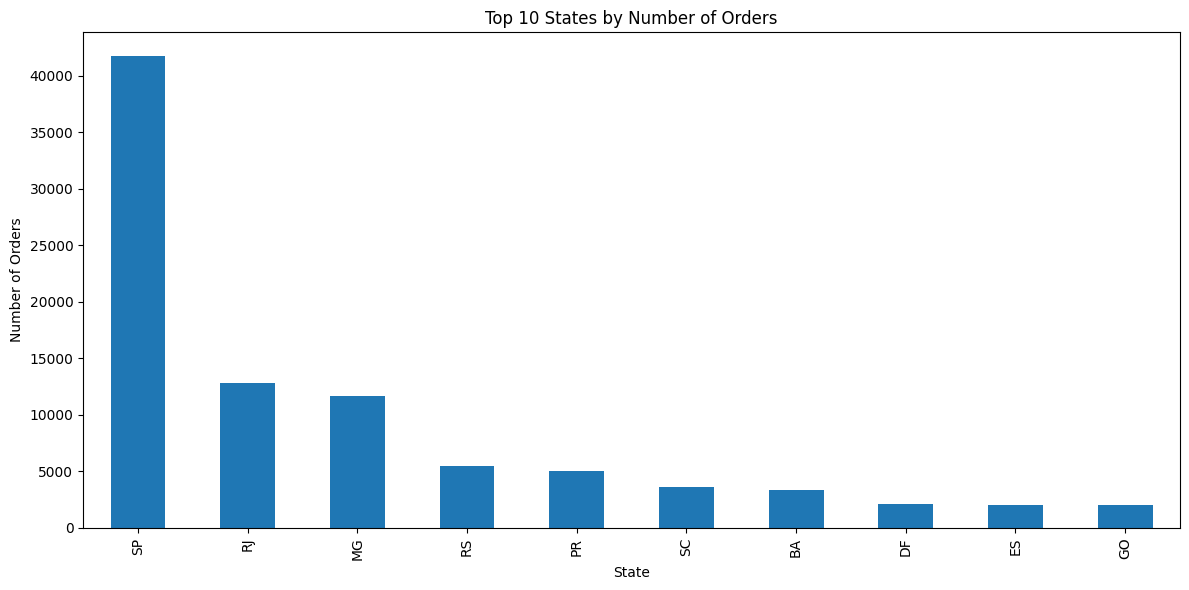

In [15]:
import matplotlib.pyplot as plt

top_states = state_orders.head(10)

plt.figure(figsize=(12,6))
top_states.plot(kind='bar')

plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [16]:
print(state_orders.head(10))

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
dtype: int64


In [17]:
# Calculate Average Order Value

average_order_value = order_items.groupby(
    'order_id'
)['price'].sum()

print("Average Order Value:")
print(round(average_order_value.mean(), 2))

Average Order Value:
137.75


In [18]:
# Order value per order

order_value = order_items.groupby(
    'order_id'
)['price'].sum().reset_index()

# Merge with orders

aov_data = pd.merge(
    order_value,
    orders[['order_id', 'month']],
    on='order_id'
)

monthly_aov = aov_data.groupby(
    'month'
)['price'].mean()

print(monthly_aov.head())

month
2016-09     89.120000
2016-10    160.739156
2016-12     10.900000
2017-01    152.487795
2017-02    142.702262
Freq: M, Name: price, dtype: float64


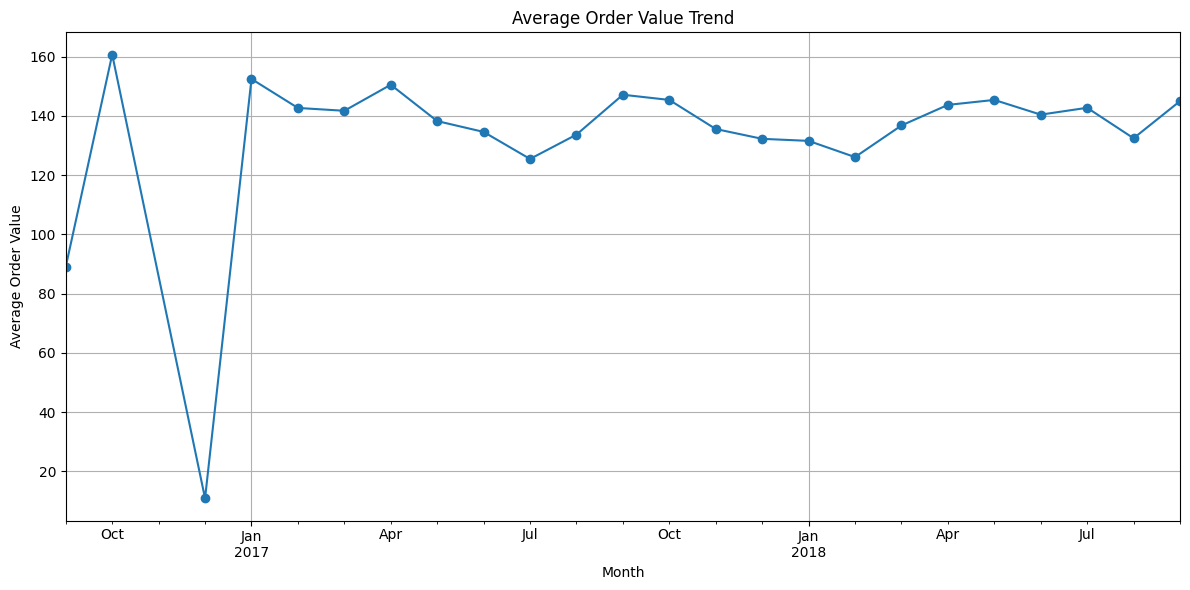

In [19]:
import matplotlib.pyplot as plt

monthly_aov.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
)

plt.title('Average Order Value Trend')
plt.xlabel('Month')
plt.ylabel('Average Order Value')

plt.grid(True)
plt.tight_layout()

plt.show()

In [20]:
print(reviews.columns)

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')


In [21]:
review_distribution = reviews['review_score'].value_counts().sort_index()

print(review_distribution)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


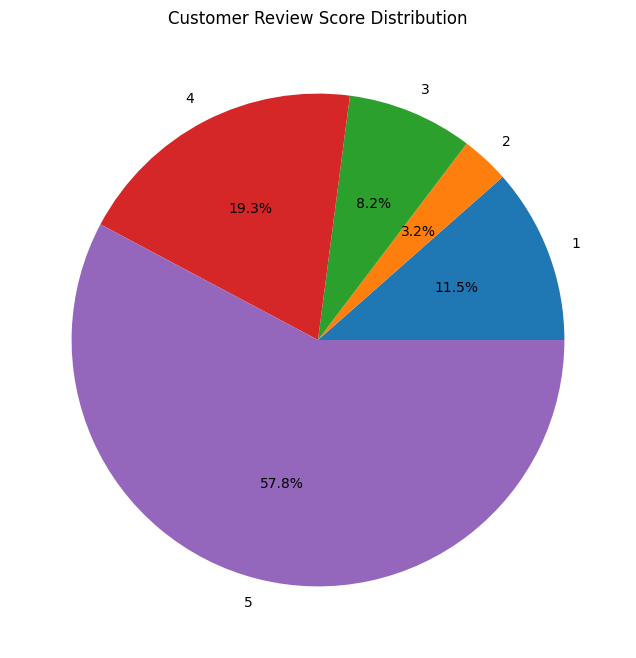

In [22]:
import matplotlib.pyplot as plt

review_distribution.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Customer Review Score Distribution')
plt.ylabel('')

plt.show()

In [24]:
# Add month column to sales data

sales_data = pd.merge(
    sales_data,
    orders[['order_id', 'month']],
    on='order_id',
    how='left'
)

# Create pivot table

# The merge operation likely resulted in 'month_x' and 'month_y' columns
# because 'sales_data' might have already contained a 'month' column from a previous,
# unrecorded operation. We will use 'month_y' as it represents the month from the 'orders' DataFrame.
heatmap_data = sales_data.pivot_table(
    values='price',
    index='product_category_name',
    columns='month_y', # Changed from 'month' to 'month_y'
    aggfunc='sum',
    fill_value=0
)

# Top 10 categories only

top_categories = category_revenue.head(10).index

heatmap_data = heatmap_data.loc[top_categories]

KeyError: 'month'

In [25]:
print(sales_data.columns)

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'month_x', 'month_y'],
      dtype='object')


In [26]:
sales_data = sales_data.rename(
    columns={'month_y': 'month'}
)

In [27]:
heatmap_data = sales_data.pivot_table(
    values='price',
    index='product_category_name',
    columns='month',
    aggfunc='sum',
    fill_value=0
)

In [28]:
sales_data = pd.merge(
    sales_data,
    orders[['order_id','month']],
    on='order_id'
)

MergeError: Passing 'suffixes' which cause duplicate columns {'month_x'} is not allowed.

In [29]:
# Use the existing month_y column

heatmap_data = sales_data.pivot_table(
    values='price',
    index='product_category_name',
    columns='month_y',
    aggfunc='sum',
    fill_value=0
)

top_categories = category_revenue.head(10).index

heatmap_data = heatmap_data.loc[top_categories]

print(heatmap_data.head())

KeyError: 'month_y'

In [30]:
print(sales_data.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'month_x', 'month']


In [31]:
heatmap_data = sales_data.pivot_table(
    values='price',
    index='product_category_name',
    columns='month',
    aggfunc='sum',
    fill_value=0
)

top_categories = category_revenue.head(10).index

heatmap_data = heatmap_data.loc[top_categories]

print(heatmap_data.head())

month                   2016-09  2016-10  2016-12   2017-01   2017-02  \
product_category_name                                                   
beleza_saude             134.97  4552.51      0.0  12561.32  22838.79   
relogios_presentes         0.00  3360.24      0.0   8086.52  11756.21   
cama_mesa_banho            0.00   478.99      0.0   3960.16  16282.73   
esporte_lazer              0.00  3333.64      0.0   9717.62  16372.16   
informatica_acessorios     0.00  1399.32      0.0   3924.14  11972.59   

month                    2017-03   2017-04   2017-05   2017-06   2017-07  ...  \
product_category_name                                                     ...   
beleza_saude            25995.25  22935.75  46786.02  32029.39  34896.86  ...   
relogios_presentes      26770.38  23487.78  37973.90  28948.63  36804.56  ...   
cama_mesa_banho         25773.02  24347.69  33346.45  35114.81  63888.75  ...   
esporte_lazer           27001.59  24864.33  36163.50  32898.33  38813.41  ...   
in

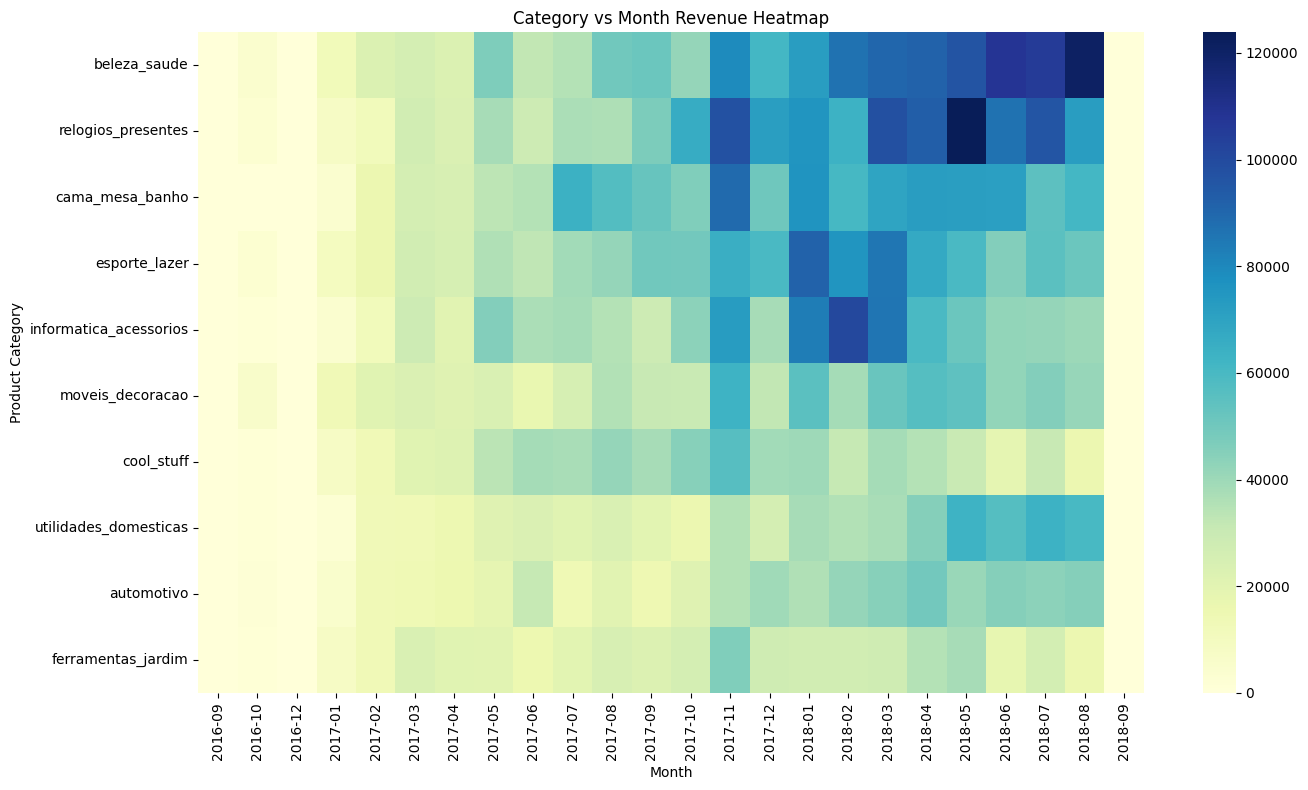

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title('Category vs Month Revenue Heatmap')
plt.xlabel('Month')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()